# Tolerance Stack-up Analysis

Worst-case 1-D limit method (S10, Fischer 2nd ed.). Picked worst case rather than RSS because this is a
qty 1–5 prototype batch with no process-capability data to root-sum.

This notebook reproduces the two calculation scripts as one document:

1. **`stackup-analysis.py`** — the numeric stack-ups, printed (Stacks 1, 2, 3 + adopted decisions).
2. **`plot_stackups.py`** — the worst-case horizontal bar-chart figure, rendered inline.

Every plotted number is *derived* from the same primitive inputs used by the analysis, so the figure
cannot silently disagree with the calculation. Source of record: `dfm/docs/stackup.md` §2–3.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

## Part 1: Stack-up analysis

Every input traced to a Phase 0–4 source doc. Reproduces the numbers in `docs/stackup.md`.

In [ ]:
# Tolerance stack-up: worst-case 1-D limit method (S10)
# Every input traced to a Phase 0-4 source doc. Reproduces the numbers in docs/stackup.md.

def band(x): return f"{x:+.4f}"

print("="*70)
print("STACK 1: Analysis link for throat-wall CTQ band -> DeltaT / stress")
print("="*70)

t_data = {3:(1.33,3.9414,53.27), 4:(2.10,4.9171,42.70), 5:(2.71,6.1812,33.96)}                  # (dT[K], sigma_vM[MPa], FoS)
sy = 209.95                                                                                     # MPa at 530.44 C (interp), Phase5b 2.3

def interp(t, idx):                                                                             # interpolation of thicknes, t (mm) for through-wall temperature difference, von Mises stressm, FoS
    lo = 4 if t>=4 else 3
    hi = lo+1
    f = (t-lo)/(hi-lo)
    a,b = t_data[lo][idx], t_data[hi][idx]
    return a + f*(b-a)

t_nom = 4.00                                                                                    # WALL BAND (T3, protect-minimum unilateral): 4 +0.3 / -0  (matches drawing CDN-001)
t_lo, t_hi = 4.00, 4.30                                                                         # Design intent: 4.00 +0.30 / 0.00 (matches drawing CDN-001)
for label,t in [("min wall (4.00)",t_lo),("nominal (4.00)",t_nom),("max wall (4.30)",t_hi)]:
    dT  = interp(t,0); sig = interp(t,1); fos = sy/sig
    print(f"  {label:16s}: dT={dT:5.3f} K  sigma_vM={sig:5.3f} MPa  FoS(yield)={fos:5.1f}")
sig_lo, sig_hi = interp(t_lo,1), interp(t_hi,1)
print(f"  Stress excursion across band |d.sigma| = {abs(sig_hi-sig_lo):.3f} MPa")
print(f"  Yield margin at worst point  = {sy - max(sig_lo,sig_hi):.1f} MPa (FoS >= {sy/max(sig_lo,sig_hi):.1f})")
print(f"  T_throat identical across t (Dirichlet): 803.59 K -> creep-governed, BC/t-insensitive")

STACK 1 — ANALYSIS-LINK: throat-wall CTQ band -> DeltaT / stress
  min wall (4.00) : dT=2.100 K  sigma_vM=4.917 MPa  FoS(yield)= 42.7
  nominal (4.00)  : dT=2.100 K  sigma_vM=4.917 MPa  FoS(yield)= 42.7
  max wall (4.30) : dT=2.283 K  sigma_vM=5.296 MPa  FoS(yield)= 39.6
  Stress excursion across band |d.sigma| = 0.379 MPa
  Yield margin at worst point  = 204.7 MPa (FoS >= 39.6)
  T_throat identical across t (Dirichlet): 803.59 K -> creep-governed, BC/t-insensitive


In [ ]:
print("="*70)
print("STACK 2 — MISALIGNMENT / CONCENTRICITY (radial, worst-case)")
print("="*70)
# 2a Throat-axis-to-mount-axis
# Pilot H7/g6 @ Ø92.80 (>80-100 band). ISO 286-2 (CONFIRM printed row C-2r)

H7 = (0.000, 0.035); g6 = (-0.012, -0.034)                                                          # mm, hole & shaft deviations
cl_max = H7[1] - g6[1]                                                                              # max clearance = largest hole - smallest shaft
cl_min = H7[0] - g6[0]                                                                              # min clearance = smallest hole - largest shaft
pilot_float_radial = cl_max/2
runout_TIR = 0.05                                                                                   # FCF #6 total runout A|B (T3 value)
runout_radial = runout_TIR/2
concentric_wc = pilot_float_radial + runout_radial
accept = 0.10                                                                                       # T3 engineering judgment (ground-test prototype)
print(f"  Pilot fit  H7={H7} g6={g6}  -> clearance {cl_min:+.3f}..{cl_max:+.3f} (dia)")
print(f"  Pilot float (radial)        = {pilot_float_radial:.4f} mm")
print(f"  Body throat->pilot runout   = {runout_TIR:.3f} TIR -> {runout_radial:.4f} mm radial")
print(f"  Worst-case concentricity    = {concentric_wc:.4f} mm  vs accept <= {accept} (T3)")
print(f"  Margin ratio                = {accept/concentric_wc:.2f}x  -> {'PASS' if concentric_wc<=accept else 'FAIL'}")

# 2b Bolt-pattern assemblability (floating fastener, both parts) w/ pilot float
H, F = 9.0, 8.0                                                                                     # clearance hole, fastener OD
T_pos = H - F                                                                                       # floating-fastener position tol @ MMC (dia)
e_pattern = T_pos/2                                                                                 # radial position error per part at MMC
avail_radial = (H-F)/2                                                                              # radial clearance per hole at MMC
need = e_pattern + e_pattern + pilot_float_radial
have = avail_radial + avail_radial
print(f"\n  [2b] Floating-fastener assemblability at strict MMC:")
print(f"       required (2*T/2 + pilot float) = {need:.4f} mm")
print(f"       available (2 * radial clear)   = {have:.4f} mm")
overrun = need - have
print(f"       overrun = {overrun:+.4f} mm  (covered by MMC bonus once holes > Ø{F + 2*overrun:.3f})")
T_pos_safe = (H - F) - 2*pilot_float_radial
print(f"       pilot-robust position tol      = ⌀{T_pos_safe:.3f} (round to ⌀0.9) if bonus not relied on")

STACK 2 — MISALIGNMENT / CONCENTRICITY (radial, worst-case)
  Pilot fit  H7=(0.0, 0.035) g6=(-0.012, -0.034)  -> clearance +0.012..+0.069 (dia)
  Pilot float (radial)        = 0.0345 mm
  Body throat->pilot runout   = 0.050 TIR -> 0.0250 mm radial
  Worst-case concentricity    = 0.0595 mm  vs accept <= 0.1 (T3)
  Margin ratio                = 1.68x  -> PASS

  [2b] Floating-fastener assemblability at strict MMC:
       required (2*T/2 + pilot float) = 1.0345 mm
       available (2 * radial clear)   = 1.0000 mm
       overrun = +0.0345 mm  (covered by MMC bonus once holes > Ø8.069)
       pilot-robust position tol      = ⌀0.931 (round to ⌀0.9) if bonus not relied on


In [8]:
print("="*70)
print("STACK 3 — AXIAL TIP-FLOOR GAP (joint's #1 flagged item)")
print("="*70)
# gap = recess_depth - (spigot_proj - gasket_compressed)   [seated/compressed]
# General tol (title-block table §8): 0.5-6 mm -> ±0.1
S_nom, D_nom = 4.75, 4.00
g_seat = 1.0                 # compressed seated thickness (~1.0-1.1; APX2 HOCHDRUCK F36 37%, C-5r resolved 2026-08-12)
tol_gen = 0.10
def gap(D,S,g): return D - (S - g)
print(f"  Relation: gap = recess_depth - (spigot_proj - gasket_compressed)")
print(f"  Nominal: gap = {D_nom} - ({S_nom} - {g_seat}) = {gap(D_nom,S_nom,g_seat):.3f} mm")
# Worst case (min gap): D min, S max, g min
g_wc = gap(D_nom-tol_gen, S_nom+tol_gen, g_seat)          # gasket at design min 1.0
g_wc_over = gap(D_nom-tol_gen, S_nom+tol_gen, g_seat-0.1) # + gasket over-compression to 0.9
print(f"  Worst-case (gen ±0.1, g=1.0):  gap = {g_wc:+.3f} mm")
print(f"  + gasket over-compress (g=0.9): gap = {g_wc_over:+.3f} mm  -> {'NEGATIVE: metal bottoms' if g_wc_over<0 else 'ok'}")
# Fix A: deepen recess 4.0 -> 4.5
D_A = 4.5
gA = gap(D_A-tol_gen, S_nom+tol_gen, g_seat-0.1)
print(f"  FIX A deepen recess -> {D_A}: worst-case (g=0.9) gap = {gA:+.3f} mm -> PASS")
# Fix B: tighten S & D tol to ±0.05
tol_t = 0.05
gB = gap(D_nom-tol_t, S_nom+tol_t, g_seat-0.1)
print(f"  FIX B tighten S,D to ±0.05:    worst-case (g=0.9) gap = {gB:+.3f} mm -> {'PASS' if gB>0 else 'marginal'}")

# secondary: min register engagement = spigot - gasket - mouth chamfer (worst = S min, g max, chamfer max)
ch=0.75
E_min = (S_nom-tol_gen) - 1.5 - (ch+tol_gen)   # pre-compression free gasket 1.5, chamfer max
print(f"\n  [secondary] min register engagement (S min, free gasket 1.5, chamfer max) = {E_min:.2f} mm (>2 target)")

STACK 3 — AXIAL TIP-FLOOR GAP (joint's #1 flagged item)
  Relation: gap = recess_depth - (spigot_proj - gasket_compressed)
  Nominal: gap = 4.0 - (4.75 - 1.0) = 0.250 mm
  Worst-case (gen ±0.1, g=1.0):  gap = +0.050 mm
  + gasket over-compress (g=0.9): gap = -0.050 mm  -> NEGATIVE: metal bottoms
  FIX A deepen recess -> 4.5: worst-case (g=0.9) gap = +0.450 mm -> PASS
  FIX B tighten S,D to ±0.05:    worst-case (g=0.9) gap = +0.050 mm -> PASS

  [secondary] min register engagement (S min, free gasket 1.5, chamfer max) = 2.30 mm (>2 target)


In [9]:
print("="*70)
print("ADOPTED DECISIONS (2026-08-04)")
print("="*70)
D_adopt=4.5
print(f"  Stack 3 FIX A: recess {D_nom}->{D_adopt} mm")
print(f"    nominal gap = {gap(D_adopt,S_nom,g_seat):.3f} mm ; worst-case (g=0.9) = {gap(D_adopt-tol_gen,S_nom+tol_gen,g_seat-0.1):+.3f} mm -> PASS")
print(f"  Stack 2b: bolt position tightened to ⌀0.9 (T_safe={T_pos_safe:.3f}, bonus-independent)")

ADOPTED DECISIONS (2026-08-04)
  Stack 3 FIX A: recess 4.0->4.5 mm
    nominal gap = 0.750 mm ; worst-case (g=0.9) = +0.450 mm -> PASS
  Stack 2b: bolt position tightened to ⌀0.9 (T_safe=0.931, bonus-independent)


## Part 2 — Worst-case stack-up figure (horizontal bar chart)

Displays the figure inline **and** writes `dfm/images/stackup-summary.png` in the same step, so
viewing the plot always refreshes the saved PNG (same output the standalone `plot_stackups.py` produces).
Every number plotted is derived from the same primitive inputs used above (fit deviations, hole/fastener
sizes, nominal lengths, general tolerance), so the figure cannot silently disagree with the calculation.

**Scope note:** Stack 1 (analysis-link, throat-wall band → stress) is deliberately *not* plotted. It is
a sensitivity propagation through an FEA response surface, not an additive dimensional stack; drawing
it as a contributor bar would assert a method it does not use.

**Note on glyphs:** the MMC modifier is written `(M)` rather than the circled-M character, which is
absent from the default Matplotlib font. On the drawings it is the circled symbol per ASME Y14.5-2018.

wrote C:\Users\baitbydcj-\Desktop\Aero Portfolio\Official Github Commit\C-D-Nozzle\dfm\images\stackup-summary.png
  A  concentricity 0.0595 vs 0.10  -> 1.68x
  B  required 1.0345 / 0.9345 vs available 1.0000
  C  gap pre -0.050 -> post +0.450


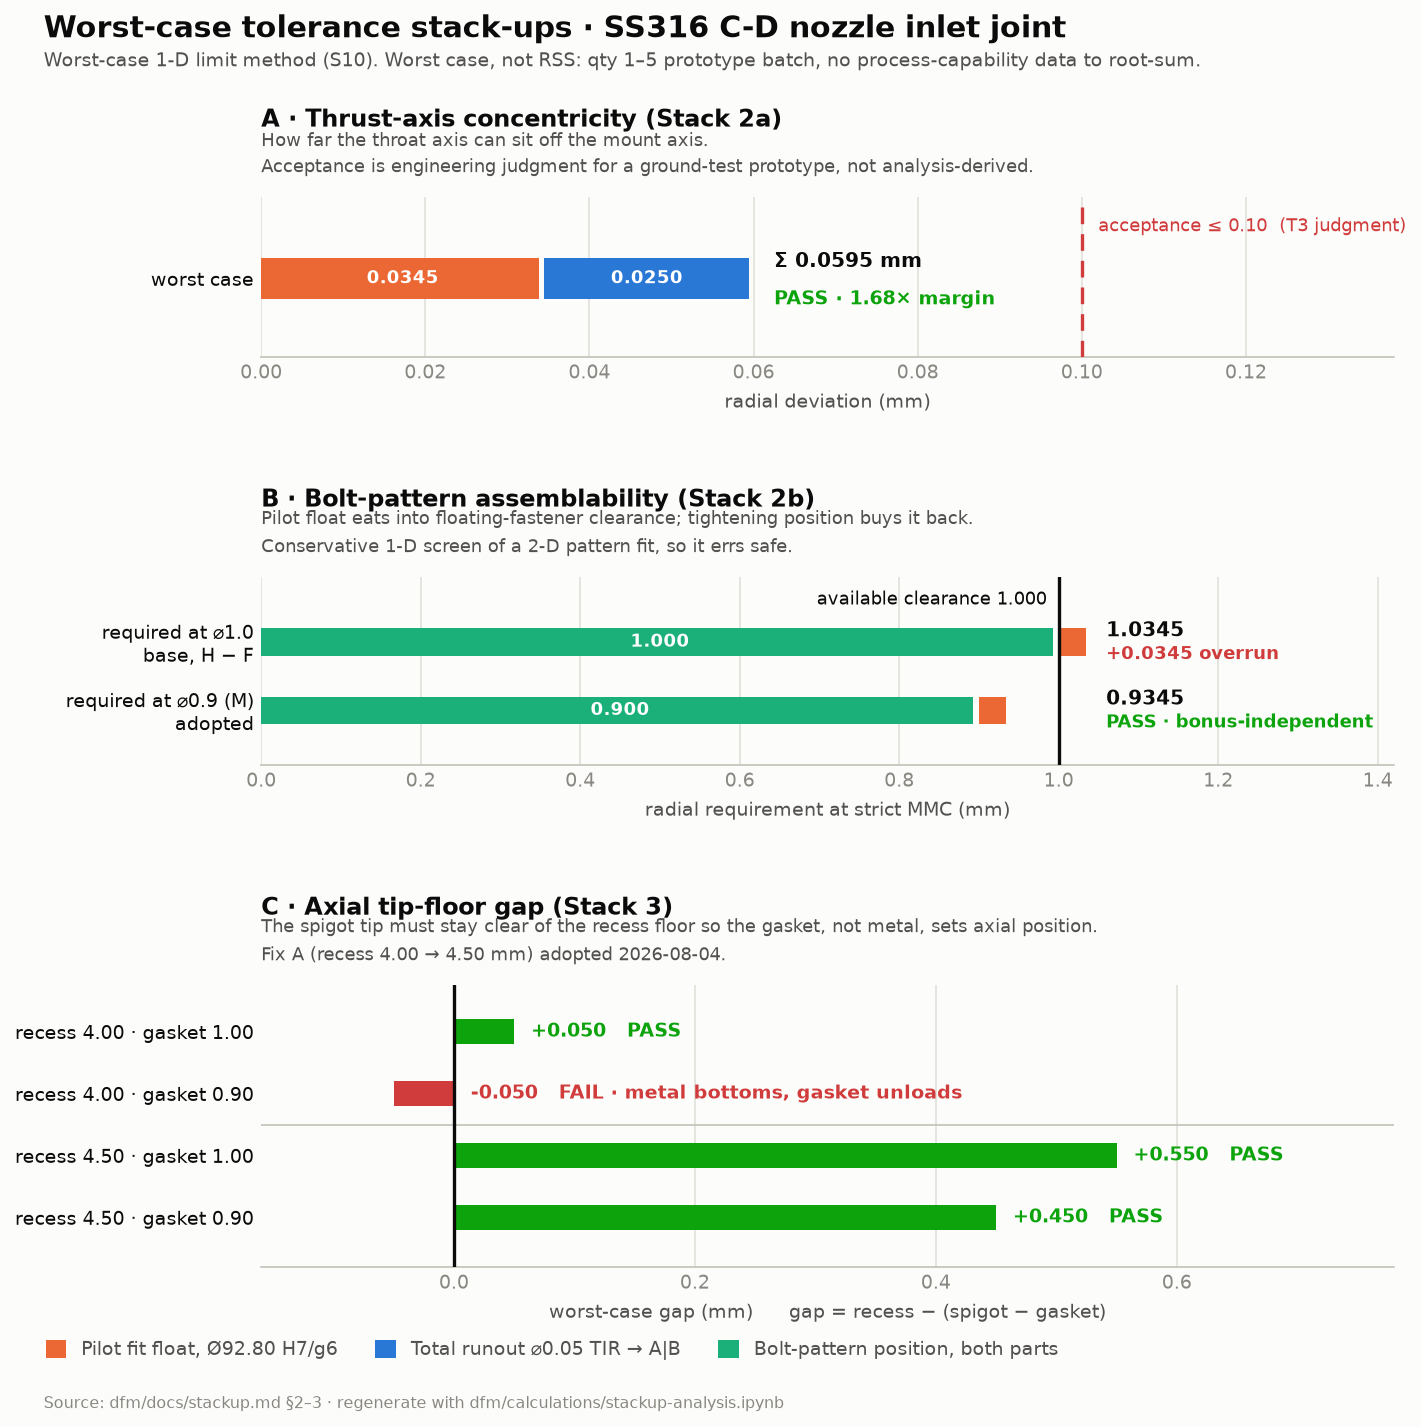

In [6]:
# Self-contained: run THIS cell alone to view + save the figure (no other cell required).
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

# ----------------------------------------------------------------------------
# PRIMITIVE INPUTS  (mirror of the analysis above)
# ----------------------------------------------------------------------------
H7 = (0.000, +0.035)      # hole deviations, Ø92.80 pilot bore    ISO 286-2
g6 = (-0.012, -0.034)     # shaft deviations, Ø92.80 pilot        ISO 286-2
RUNOUT_TIR = 0.05         # total runout, throat -> pilot, A|B    CDN-001 FCF 6
ACCEPT_CONC = 0.10        # acceptance, radial                    T3 judgment

HOLE = 9.0                # clearance hole Ø                      ISO 273 medium
BOLT = 8.0                # fastener Ø, M8
POS_ADOPTED = 0.9         # adopted position tolerance            DECIDED 2026-08-04

SPIGOT = 4.75             # spigot projection, Part 1
RECESS_OLD = 4.00         # recess depth, Part 2, pre-fix
RECESS_NEW = 4.50         # recess depth, Part 2, Fix A adopted
GASKET_SEAT = 1.00        # compressed seated thickness, APX2
GASKET_OVER = 0.90        # over-compressed bound
TOL_GEN = 0.10            # general tolerance, 0.5-6 mm band

# ----------------------------------------------------------------------------
# DERIVED
# ----------------------------------------------------------------------------
pilot_float = (H7[1] - g6[1]) / 2.0          # max diametral clearance -> radial
runout_radial = RUNOUT_TIR / 2.0
conc_wc = pilot_float + runout_radial

per_part_base = (HOLE - BOLT) / 2.0
per_part_adopt = POS_ADOPTED / 2.0
avail = 2 * per_part_base
req_base = 2 * per_part_base + pilot_float
req_adopt = 2 * per_part_adopt + pilot_float


def gap(recess, spigot, gasket):
    return recess - (spigot - gasket)


gap_pre_wc = gap(RECESS_OLD - TOL_GEN, SPIGOT + TOL_GEN, GASKET_SEAT)
gap_pre_over = gap(RECESS_OLD - TOL_GEN, SPIGOT + TOL_GEN, GASKET_OVER)
gap_new_wc = gap(RECESS_NEW - TOL_GEN, SPIGOT + TOL_GEN, GASKET_SEAT)
gap_new_over = gap(RECESS_NEW - TOL_GEN, SPIGOT + TOL_GEN, GASKET_OVER)

# ----------------------------------------------------------------------------
# PALETTE  (validated light-mode, adjacent and all-pairs CVD gates)
# ----------------------------------------------------------------------------
SURFACE = "#fcfcfb"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C_RUNOUT = "#2a78d6"      # slot 1 blue
C_PILOT = "#eb6834"       # slot 2 orange  (same entity keeps its hue, panels A+B)
C_PATTERN = "#1baf7a"     # slot 3 aqua
C_GOOD, C_CRIT = "#0ca30c", "#d03b3b"

BAR_H = 0.40


def style(ax, xlim, xlabel):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.xaxis.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel, color=INK_2, fontsize=9, labelpad=5)
    for lbl in ax.get_yticklabels():
        lbl.set_color(INK)
        lbl.set_fontsize(9.2)


def header(ax, title, desc, r):
    """r = this panel's height ratio; offsets are scaled so the header sits a
    constant physical distance above every panel regardless of its height."""
    ax.text(0, 1 + 0.345 / r, title, transform=ax.transAxes, color=INK,
            fontsize=11.5, weight="bold", va="bottom")
    ax.text(0, 1 + 0.085 / r, desc, transform=ax.transAxes, color=INK_2,
            fontsize=8.7, va="bottom", linespacing=1.55)


def stacked(ax, y, segs, gapw):
    left = 0.0
    for i, (val, col) in enumerate(segs):
        w = val - (gapw if i < len(segs) - 1 else 0.0)
        ax.barh(y, w, left=left, height=BAR_H, color=col, zorder=3)
        left += val
    return left

# ----------------------------------------------------------------------------
# FIGURE
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10.0, 9.6), dpi=150,
                         gridspec_kw={"height_ratios": [0.85, 1.0, 1.5],
                                      "hspace": 1.05})
fig.patch.set_facecolor(SURFACE)

# ============================================================================
# PANEL A — concentricity
# ============================================================================
ax = axes[0]
style(ax, (0, 0.138), "radial deviation (mm)")
header(ax, "A · Thrust-axis concentricity (Stack 2a)",
       "How far the throat axis can sit off the mount axis.\n"
       "Acceptance is engineering judgment for a ground-test prototype, not analysis-derived.", 0.85)

stacked(ax, 0, [(pilot_float, C_PILOT), (runout_radial, C_RUNOUT)], gapw=0.0007)
ax.axvline(ACCEPT_CONC, color=C_CRIT, lw=1.6, ls=(0, (5, 3)), zorder=4)
ax.text(ACCEPT_CONC + 0.002, 0.50, f"acceptance ≤ {ACCEPT_CONC:.2f}  (T3 judgment)",
        color=C_CRIT, fontsize=8.5, va="center")
ax.text(pilot_float / 2, 0, f"{pilot_float:.4f}", color="white", fontsize=8.5,
        ha="center", va="center", weight="bold", zorder=5)
ax.text(pilot_float + runout_radial / 2, 0, f"{runout_radial:.4f}", color="white",
        fontsize=8.5, ha="center", va="center", weight="bold", zorder=5)
ax.text(conc_wc + 0.003, 0.16, f"Σ {conc_wc:.4f} mm", color=INK,
        fontsize=9.5, va="center", weight="bold")
ax.text(conc_wc + 0.003, -0.20, f"PASS · {ACCEPT_CONC / conc_wc:.2f}× margin",
        color=C_GOOD, fontsize=9, va="center", weight="bold")
ax.set_yticks([0])
ax.set_yticklabels(["worst case"])
ax.set_ylim(-0.75, 0.78)

# ============================================================================
# PANEL B — bolt-pattern assemblability
# ============================================================================
ax = axes[1]
style(ax, (0, 1.42), "radial requirement at strict MMC (mm)")
header(ax, "B · Bolt-pattern assemblability (Stack 2b)",
       "Pilot float eats into floating-fastener clearance; tightening position buys it back.\n"
       "Conservative 1-D screen of a 2-D pattern fit, so it errs safe.", 1.0)

stacked(ax, 1, [(2 * per_part_base, C_PATTERN), (pilot_float, C_PILOT)], gapw=0.007)
stacked(ax, 0, [(2 * per_part_adopt, C_PATTERN), (pilot_float, C_PILOT)], gapw=0.007)
ax.axvline(avail, color=INK, lw=1.6, zorder=4)
ax.text(avail - 0.015, 1.62, f"available clearance {avail:.3f}", color=INK,
        fontsize=8.6, va="center", ha="right")
ax.text(2 * per_part_base / 2, 1, f"{2*per_part_base:.3f}", color="white",
        fontsize=8.5, ha="center", va="center", weight="bold", zorder=5)
ax.text(2 * per_part_adopt / 2, 0, f"{2*per_part_adopt:.3f}", color="white",
        fontsize=8.5, ha="center", va="center", weight="bold", zorder=5)
LBL_X = max(req_base, avail) + 0.025
ax.text(LBL_X, 1.16, f"{req_base:.4f}", color=INK, fontsize=9.5,
        va="center", weight="bold")
ax.text(LBL_X, 0.82, f"+{req_base - avail:.4f} overrun", color=C_CRIT,
        fontsize=8.8, va="center", weight="bold")
ax.text(LBL_X, 0.16, f"{req_adopt:.4f}", color=INK, fontsize=9.5,
        va="center", weight="bold")
ax.text(LBL_X, -0.18, "PASS · bonus-independent", color=C_GOOD,
        fontsize=8.8, va="center", weight="bold")
ax.set_yticks([1, 0])
ax.set_yticklabels(["required at ⌀1.0\nbase, H − F", "required at ⌀0.9 (M)\nadopted"])
ax.set_ylim(-0.8, 1.95)

# ============================================================================
# PANEL C — axial tip-floor gap
# ============================================================================
ax = axes[2]
style(ax, (-0.16, 0.78), "worst-case gap (mm)      gap = recess − (spigot − gasket)")
header(ax, "C · Axial tip-floor gap (Stack 3)",
       "The spigot tip must stay clear of the recess floor so the gasket, not metal, sets axial position.\n"
       "Fix A (recess 4.00 → 4.50 mm) adopted 2026-08-04.", 1.5)

rows = [
    (3, gap_pre_wc,   f"recess {RECESS_OLD:.2f} · gasket {GASKET_SEAT:.2f}"),
    (2, gap_pre_over, f"recess {RECESS_OLD:.2f} · gasket {GASKET_OVER:.2f}"),
    (1, gap_new_wc,   f"recess {RECESS_NEW:.2f} · gasket {GASKET_SEAT:.2f}"),
    (0, gap_new_over, f"recess {RECESS_NEW:.2f} · gasket {GASKET_OVER:.2f}"),
]
for y, val, _ in rows:
    col = C_GOOD if val > 0 else C_CRIT
    ax.barh(y, val, height=BAR_H, color=col, zorder=3)
    tag = "PASS" if val > 0 else "FAIL · metal bottoms, gasket unloads"
    x = max(val, 0.0) + 0.014
    ax.text(x, y, f"{val:+.3f}   {tag}", color=col, fontsize=9,
            va="center", ha="left", weight="bold", zorder=5)

ax.axvline(0, color=INK, lw=1.6, zorder=4)
ax.axhline(1.5, color=AXIS, lw=0.8, zorder=2)
ax.set_yticks([r[0] for r in rows])
ax.set_yticklabels([r[2] for r in rows])
ax.set_ylim(-0.8, 3.75)

# ============================================================================
# CHROME
# ============================================================================
fig.text(0.055, 0.975, "Worst-case tolerance stack-ups · SS316 C-D nozzle inlet joint",
         ha="left", va="top", color=INK, fontsize=14.5, weight="bold")
fig.text(0.055, 0.949,
         "Worst-case 1-D limit method (S10). Worst case, not RSS: qty 1–5 prototype batch, "
         "no process-capability data to root-sum.",
         ha="left", va="top", color=INK_2, fontsize=9.2)

fig.legend(
    handles=[Patch(fc=C_PILOT, label="Pilot fit float, Ø92.80 H7/g6"),
             Patch(fc=C_RUNOUT, label="Total runout ⌀0.05 TIR → A|B"),
             Patch(fc=C_PATTERN, label="Bolt-pattern position, both parts")],
    loc="lower left", bbox_to_anchor=(0.05, 0.034), ncol=3, frameon=False,
    fontsize=9, labelcolor=INK_2, handlelength=1.1, handleheight=1.1,
    columnspacing=2.0, borderpad=0)
fig.text(0.055, 0.010,
         "Source: dfm/docs/stackup.md §2–3 · regenerate with dfm/calculations/stackup-analysis.ipynb",
         ha="left", va="center", color=MUTED, fontsize=7.8)

fig.subplots_adjust(left=0.20, right=0.955, top=0.848, bottom=0.105)

# Save to disk AND display inline — viewing the plot writes the PNG in one step.
out = Path.cwd().parent / "images" / "stackup-summary.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, facecolor=SURFACE, dpi=150)

print(f"wrote {out}")
print(f"  A  concentricity {conc_wc:.4f} vs {ACCEPT_CONC:.2f}  -> {ACCEPT_CONC/conc_wc:.2f}x")
print(f"  B  required {req_base:.4f} / {req_adopt:.4f} vs available {avail:.4f}")
print(f"  C  gap pre {gap_pre_over:+.3f} -> post {gap_new_over:+.3f}")

plt.show()